# Lab — Autoencoders: do AE ao VAE (SOLUÇÃO)

Neste lab vocês implementam as três ideias centrais da aula, em ordem:

1. **Autoencoder convolucional:** vocês escrevem o *decoder*.
2. **Denoising autoencoder:** vocês escrevem a corrupção da entrada (uma linha).
3. **VAE:** vocês escrevem o *reparametrization trick* e o termo de *KL*.

No fim, comparamos o espaço latente do AE e do VAE e vemos na prática o "buraco" do slide 45: por que um AE comum não serve para gerar e um VAE serve.

**Como usar:** rode as células em ordem. Os trechos que vocês devem completar estão marcados com `# TODO`, e logo depois há uma célula de teste. Use GPU no Colab (*Ambiente de execução → Alterar tipo*). Cada treino leva cerca de 1 minuto.

## 0. Setup

device: cuda


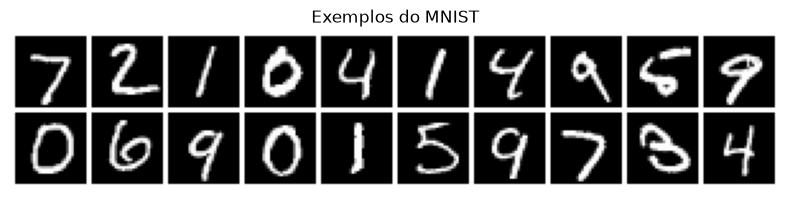

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

tf = transforms.ToTensor()  # pixels em [0, 1]
train_ds = datasets.MNIST("data", train=True, download=True, transform=tf)
test_ds = datasets.MNIST("data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

def show_grid(imgs, nrow=10, title=None):
    g = make_grid(imgs.detach().cpu(), nrow=nrow, padding=2, pad_value=1.0)
    w = min(1.0 * nrow, 14)
    plt.figure(figsize=(w, w * g.shape[1] / g.shape[2]))
    plt.imshow(g.permute(1, 2, 0)); plt.axis("off")
    if title: plt.title(title)
    plt.show()

x_test, y_test = next(iter(test_loader))
show_grid(x_test[:20], nrow=10, title="Exemplos do MNIST")

## 1. Autoencoder convolucional

O encoder já está pronto. Ele recebe uma imagem `1×28×28` e devolve um vetor de tamanho `out_dim`:

`1×28×28 → conv (stride 2) → 32×14×14 → conv (stride 2) → 64×7×7 → flatten → 256 → out_dim`

Usamos `out_dim` como parâmetro porque o mesmo encoder vai servir para o VAE na Parte 3.

In [10]:
class Encoder(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(),   # 32x14x14
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),  # 64x7x7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, out_dim),
        )

    def forward(self, x):
        return self.net(x)

### TODO 1 — o decoder

Escreva o decoder como o **espelho** do encoder:

`latent_dim → 256 → 64·7·7 → reshape para 64×7×7 → conv transposta → 32×14×14 → conv transposta → 1×28×28`

Dicas:
- `nn.ConvTranspose2d(in, out, kernel_size=4, stride=2, padding=1)` dobra a resolução espacial.
- A saída deve estar em `[0, 1]`, como os pixels. Qual ativação garante isso?

In [11]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 7 * 7), nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),  # 32x14x14
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1), nn.Sigmoid(),  # 1x28x28
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 64, 7, 7)
        return self.deconv(h)


class AE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.decoder(self.encoder(x)), {}

In [12]:
# Teste do TODO 1
out = Decoder(2)(torch.randn(5, 2))
assert out.shape == (5, 1, 28, 28), f"shape errado: {tuple(out.shape)}"
assert out.min() >= 0 and out.max() <= 1, "a saída deve estar em [0, 1]"
print("Decoder ok!")

Decoder ok!


### Loss e treino

A loss de reconstrução compara `x̂` com `x`. Como os pixels estão em `[0, 1]`, usamos **binary cross-entropy** somada sobre os pixels e média sobre o batch. A MSE dos slides também funciona; a BCE só deixa a escala compatível com o termo de KL da Parte 3.

A função `train` serve para os três modelos: ela recebe uma `loss_fn(model, x_entrada, x_alvo)`. Por enquanto entrada e alvo são a mesma imagem.

In [13]:
def recon_loss(x_hat, x):
    return F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)

def ae_loss(model, x_in, x_target):
    x_hat, _ = model(x_in)
    rec = recon_loss(x_hat, x_target)
    return rec, {"rec": rec.item()}

def train(model, loss_fn, epochs=5, lr=1e-3, noise_std=0.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        model.train()
        totals, n = {}, 0
        for x, _ in train_loader:
            x = x.to(device)
            x_in = add_noise(x, noise_std) if noise_std > 0 else x  # Parte 2
            loss, logs = loss_fn(model, x_in, x)
            opt.zero_grad(); loss.backward(); opt.step()
            for k, v in logs.items():
                totals[k] = totals.get(k, 0.0) + v
            n += 1
        print(f"época {ep + 1}: " + "  ".join(f"{k} = {v / n:.2f}" for k, v in totals.items()))
    model.eval()
    return model

Treinamos com **latente 2D** de propósito: reconstrói pior, mas permite desenhar o espaço latente inteiro.

época 1: rec = 182.00
época 2: rec = 153.28
época 3: rec = 146.75
época 4: rec = 143.60
época 5: rec = 141.53


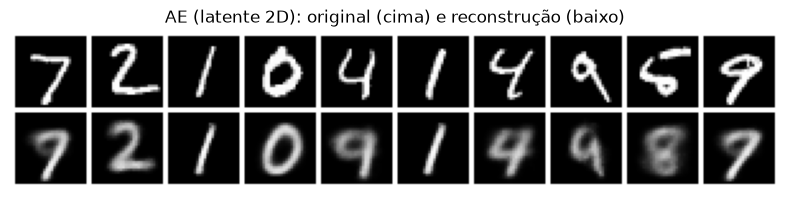

In [14]:
ae = train(AE(latent_dim=2), ae_loss, epochs=5)

with torch.no_grad():
    x_hat, _ = ae(x_test[:10].to(device))
show_grid(torch.cat([x_test[:10], x_hat.cpu()]), nrow=10, title="AE (latente 2D): original (cima) e reconstrução (baixo)")

### Olhando o espaço latente

Abaixo: (a) onde cada imagem de teste cai no espaço latente, colorida pelo dígito; (b) o que o decoder gera numa grade regular de pontos desse espaço.

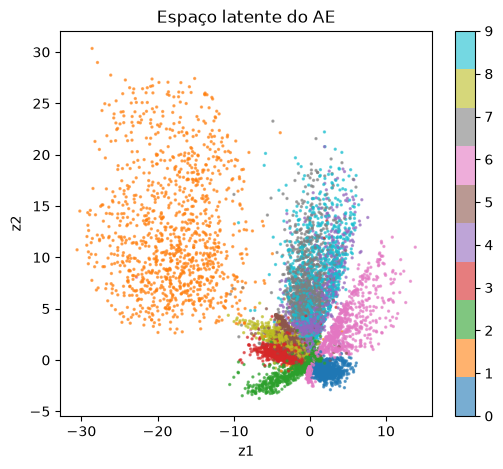

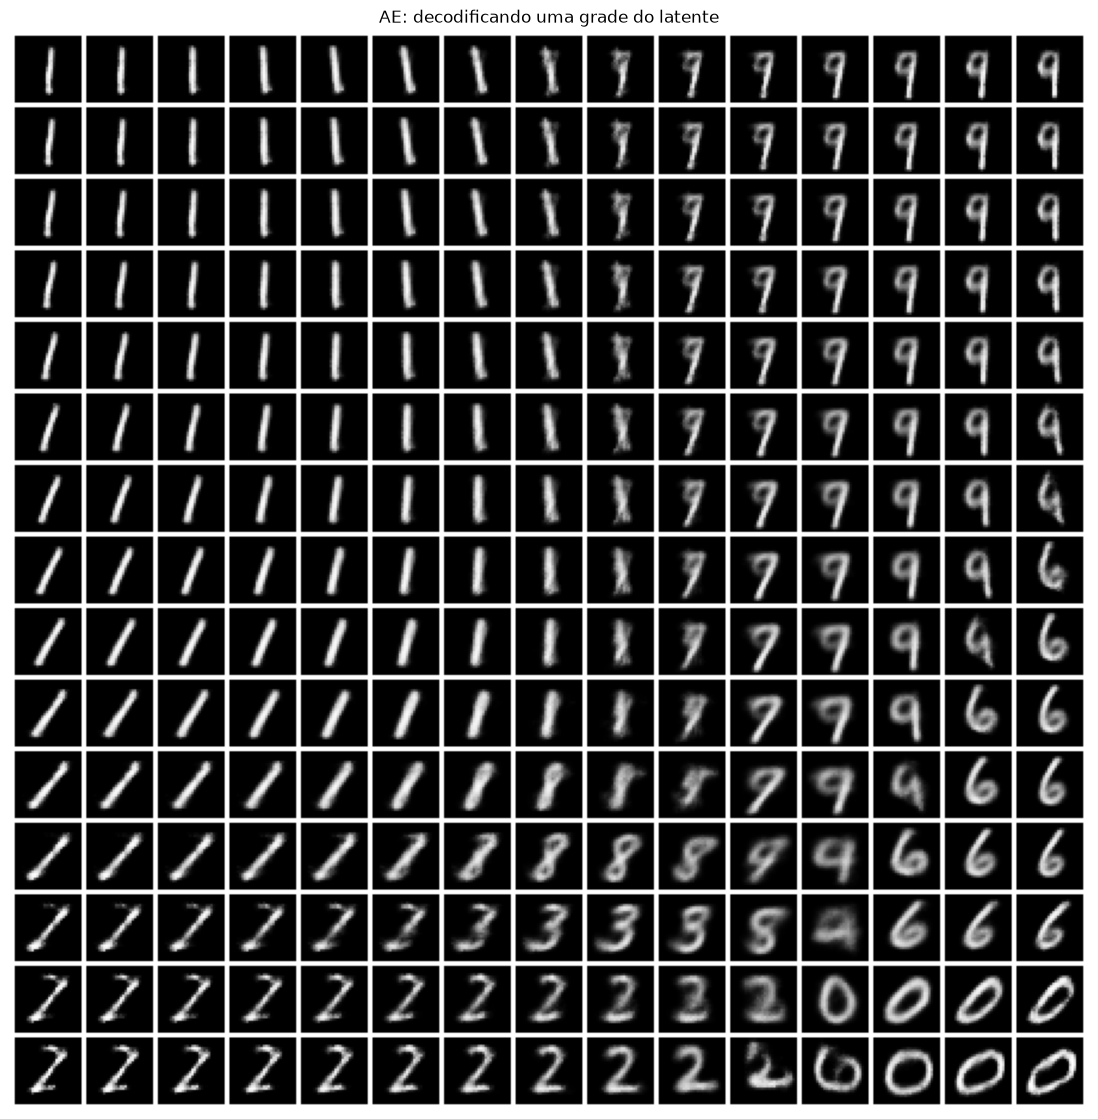

In [15]:
@torch.no_grad()
def get_latents(model):
    zs, ys = [], []
    for x, y in test_loader:
        zs.append(model.encode(x.to(device)).cpu()); ys.append(y)
    return torch.cat(zs), torch.cat(ys)

def plot_latents(z, y, title):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(z[:, 0], z[:, 1], c=y, cmap="tab10", s=2, alpha=0.6)
    plt.colorbar(sc, ticks=range(10)); plt.xlabel("z1"); plt.ylabel("z2"); plt.title(title)
    plt.show()

@torch.no_grad()
def decode_grid(model, z1_range, z2_range, n=15, title=None):
    g1 = torch.linspace(*z1_range, n)
    g2 = torch.linspace(*z2_range, n).flip(0)  # z2 alto em cima
    zz = torch.stack(torch.meshgrid(g1, g2, indexing="xy"), dim=-1).reshape(-1, 2)
    show_grid(model.decoder(zz.to(device)).cpu(), nrow=n, title=title)

z_ae, y_lat = get_latents(ae)
plot_latents(z_ae, y_lat, "Espaço latente do AE")
lo, hi = z_ae.quantile(0.01, dim=0), z_ae.quantile(0.99, dim=0)
decode_grid(ae, (lo[0].item(), hi[0].item()), (lo[1].item(), hi[1].item()), title="AE: decodificando uma grade do latente")

**Pergunte-se:**
- Os dígitos ocupam o espaço de forma contínua, ou há regiões vazias entre os grupos? Qual é a escala dos eixos?
- Na grade, o que o decoder gera nas regiões onde não caiu nenhuma imagem de treino?
- Se você quisesse **gerar** um dígito novo, de que distribuição sortearia `z`?

## 2. Denoising autoencoder

Mesmo modelo, outra tarefa: a entrada é corrompida e o alvo é a imagem limpa. Agora o modelo não consegue simplesmente copiar a entrada; ele precisa aprender como é um dígito.

### TODO 2 — corromper a entrada

Some ruído gaussiano com desvio `noise_std` e mantenha os pixels em `[0, 1]`.

In [16]:
def add_noise(x, noise_std):
    return (x + noise_std * torch.randn_like(x)).clamp(0.0, 1.0)

# Teste do TODO 2
xn = add_noise(x_test[:8], 0.5)
assert xn.shape == x_test[:8].shape and xn.min() >= 0 and xn.max() <= 1
assert (xn - x_test[:8]).abs().mean() > 0.05, "parece que não há ruído"
print("add_noise ok!")

add_noise ok!


Agora o latente tem dimensão 16: aqui o objetivo é reconstruir bem, não desenhar o espaço.

época 1: rec = 162.73
época 2: rec = 98.04
época 3: rec = 89.20
época 4: rec = 86.21
época 5: rec = 84.35


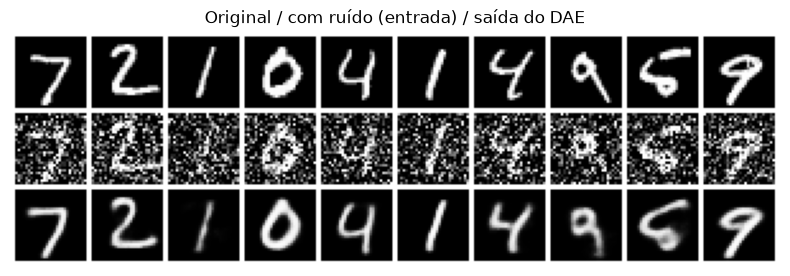

In [17]:
NOISE = 0.5
dae = train(AE(latent_dim=16), ae_loss, epochs=5, noise_std=NOISE)

torch.manual_seed(1)
x_noisy = add_noise(x_test[:10], NOISE)
with torch.no_grad():
    x_clean, _ = dae(x_noisy.to(device))
show_grid(torch.cat([x_test[:10], x_noisy, x_clean.cpu()]), nrow=10,
          title="Original / com ruído (entrada) / saída do DAE")

**Pergunte-se:**
- Na loss, a entrada é `x_in` (ruidosa) e o alvo é `x` (limpo). O que aconteceria se o alvo também fosse ruidoso, com ruído independente? Pense no exemplo de speckle em SAR dos slides 28–29.
- Teste `NOISE = 0.8`. Onde o DAE começa a "inventar" dígitos?

## 3. Variational autoencoder

Duas mudanças em relação ao AE:

1. O encoder devolve uma **distribuição** `q(z|x) = N(μ, diag(σ²))`, não um ponto. Na prática ele devolve `μ` e `log σ²` (por estabilidade numérica), por isso usamos `Encoder(2 * latent_dim)`.
2. A loss ganha o termo de KL, que puxa cada `q(z|x)` para a priori `N(0, I)`:

$$\mathcal{L} = \text{reconstrução} + \beta\,\mathrm{KL}\big(q(z\mid x)\,\Vert\,\mathcal{N}(0,I)\big)$$

### TODO 3 — reparametrization trick

Não dá para fazer backprop através de "sorteie `z` de `N(μ, σ²)`". Reescreva o sorteio de forma que a aleatoriedade venha de uma variável `ε` que não depende dos parâmetros (slide 48).

### TODO 4 — KL em forma fechada

Para `q = N(μ, diag(σ²))` e `p = N(0, I)`:

$$\mathrm{KL} = \frac{1}{2}\sum_j \left(\sigma_j^2 + \mu_j^2 - 1 - \log\sigma_j^2\right)$$

Some sobre as dimensões latentes e tire a média sobre o batch (igual à reconstrução). Atenção: a fórmula do slide 46 tem o sinal trocado e usa σ em vez de σ².

In [18]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(2 * latent_dim)  # devolve [mu, logvar]
        self.decoder = Decoder(latent_dim)

    def encode(self, x):
        mu, logvar = self.encoder(x).chunk(2, dim=1)
        return mu  # para visualizar, usamos a média de q(z|x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x).chunk(2, dim=1)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), {"mu": mu, "logvar": logvar}


def kl_divergence(mu, logvar):
    return 0.5 * torch.sum(logvar.exp() + mu.pow(2) - 1.0 - logvar) / mu.size(0)


def make_vae_loss(beta=1.0):
    def vae_loss(model, x_in, x_target):
        x_hat, out = model(x_in)
        rec = recon_loss(x_hat, x_target)
        kl = kl_divergence(out["mu"], out["logvar"])
        return rec + beta * kl, {"rec": rec.item(), "kl": kl.item()}
    return vae_loss

In [19]:
# Testes dos TODOs 3 e 4
z0 = torch.zeros(4, 2)
assert abs(kl_divergence(z0, z0).item()) < 1e-6, "KL(N(0,1) || N(0,1)) deveria ser 0"
assert abs(kl_divergence(torch.ones(1, 2), torch.zeros(1, 2)).item() - 1.0) < 1e-5, "KL com mu=1, sigma=1 em 2D deveria ser 1"
assert kl_divergence(torch.zeros(1, 2), torch.full((1, 2), -3.0)).item() > 0, "KL nunca é negativa"

mu = torch.zeros(2000, 2, requires_grad=True)
logvar = torch.full((2000, 2), np.log(4.0), requires_grad=True)  # sigma = 2
z = VAE(2).reparameterize(mu, logvar)
assert z.shape == (2000, 2)
assert 1.8 < z.std().item() < 2.2, "o desvio de z deveria ser ~2"
z.sum().backward()
assert mu.grad is not None and logvar.grad is not None, "o gradiente precisa chegar em mu e logvar"
print("reparameterize e kl_divergence ok!")

reparameterize e kl_divergence ok!


época 1: rec = 180.24  kl = 4.14
época 2: rec = 153.66  kl = 5.26
época 3: rec = 149.10  kl = 5.64
época 4: rec = 146.26  kl = 5.85
época 5: rec = 144.19  kl = 6.01


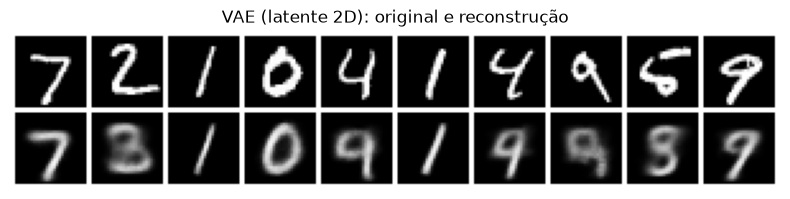

In [20]:
vae = train(VAE(latent_dim=2), make_vae_loss(beta=1.0), epochs=5)

with torch.no_grad():
    x_hat, _ = vae(x_test[:10].to(device))
show_grid(torch.cat([x_test[:10], x_hat.cpu()]), nrow=10, title="VAE (latente 2D): original e reconstrução")

### AE vs VAE: o espaço latente

Compare com os gráficos da Parte 1. Para o VAE, a grade cobre os quantis de 5% a 95% de `N(0, 1)` em cada eixo, ou seja, a região de onde a priori sorteia.

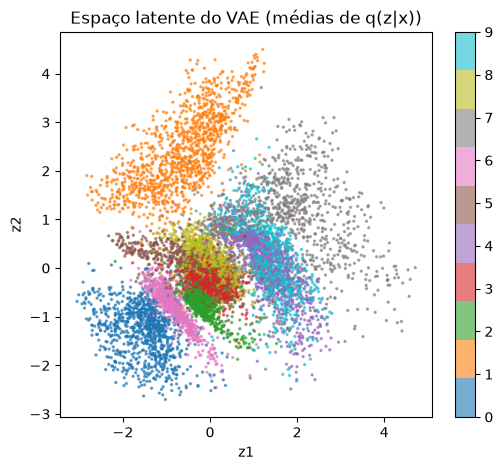

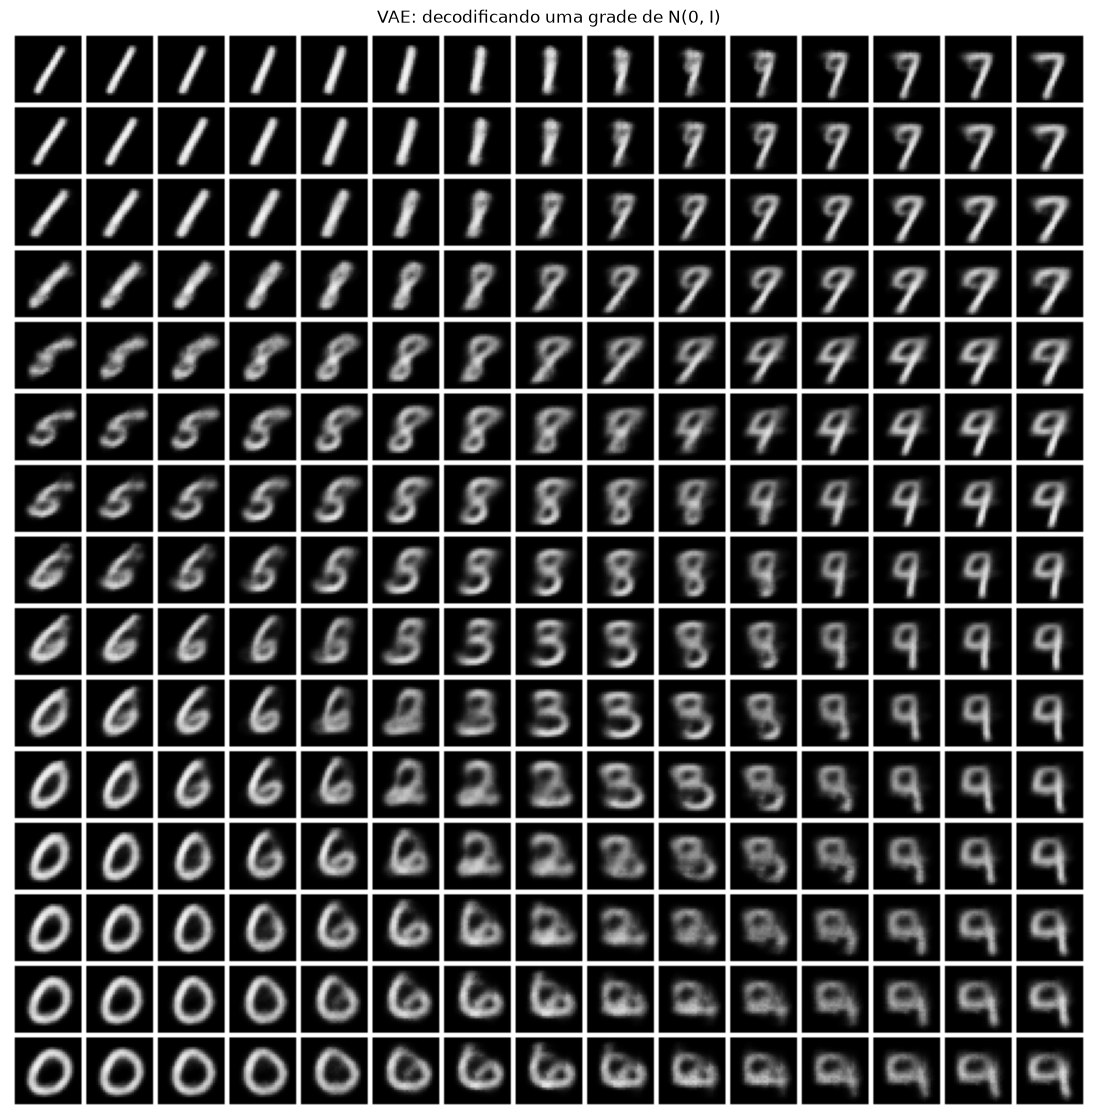

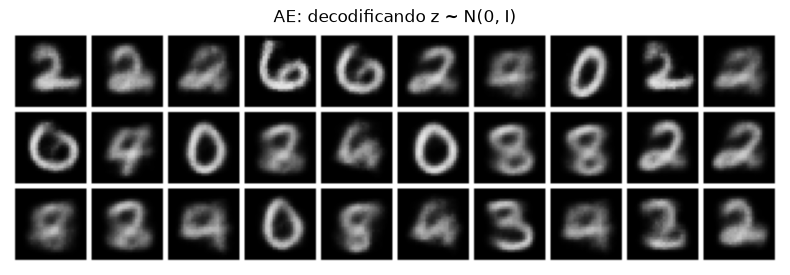

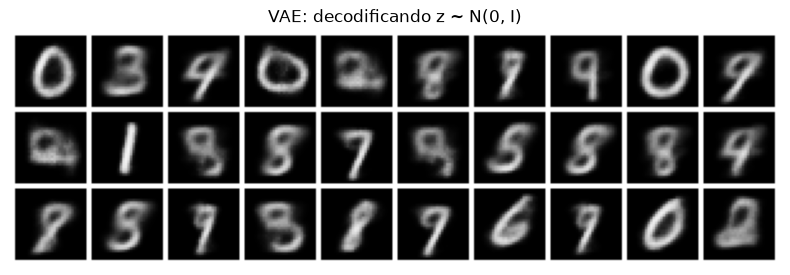

In [21]:
z_vae, _ = get_latents(vae)
plot_latents(z_vae, y_lat, "Espaço latente do VAE (médias de q(z|x))")
decode_grid(vae, (-1.64, 1.64), (-1.64, 1.64), title="VAE: decodificando uma grade de N(0, I)")

torch.manual_seed(0)
z_prior = torch.randn(30, 2).to(device)
with torch.no_grad():
    show_grid(ae.decoder(z_prior).cpu(), nrow=10, title="AE: decodificando z ~ N(0, I)")
    show_grid(vae.decoder(z_prior).cpu(), nrow=10, title="VAE: decodificando z ~ N(0, I)")

**Pergunte-se:**
- Compare os dois gráficos de dispersão: escala dos eixos, centro, regiões vazias. Qual termo da loss explica a diferença?
- Por que sortear `z ~ N(0, I)` funciona para o VAE e não para o AE?
- Andando na grade do VAE, os dígitos mudam de forma suave? Isso é a *continuidade* do slide 45.
- Por que as reconstruções do VAE são mais borradas que as do AE?

## 4. Desafios (opcionais)

**(a) O peso β.** Treine `VAE(2)` com `beta=0` e com `beta=5` e refaça os gráficos. Com `beta=0`, o que acontece com o espaço latente? Com `beta=5`, o que acontece com as reconstruções e com o valor da KL?

**(b) Amostrando "comum" e "raro".** Inspirado no gerador de clima do slide 54: em vez de sortear `z` livremente, sorteie só pontos numa faixa de distância à origem. Os dígitos das faixas externas parecem menos típicos?

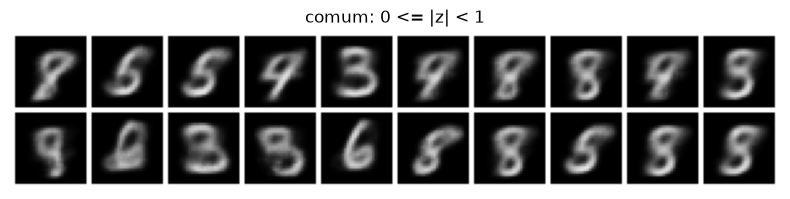

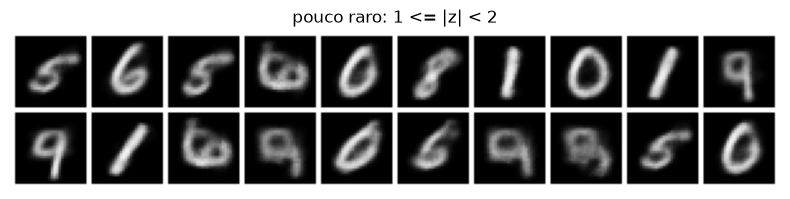

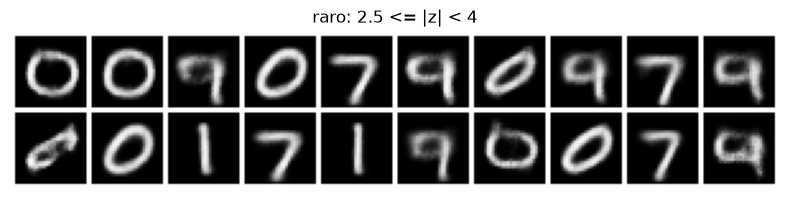

In [22]:
@torch.no_grad()
def sample_band(model, r_min, r_max, n=20):
    zs, total = [], 0
    while total < n:
        z = torch.randn(4096, model.latent_dim)
        z = z[(z.norm(dim=1) >= r_min) & (z.norm(dim=1) < r_max)]
        zs.append(z); total += len(z)
    return model.decoder(torch.cat(zs)[:n].to(device)).cpu()

for r_min, r_max, nome in [(0, 1, "comum"), (1, 2, "pouco raro"), (2.5, 4, "raro")]:
    show_grid(sample_band(vae, r_min, r_max), nrow=10, title=f"{nome}: {r_min} <= |z| < {r_max}")